In [1]:
import numpy as np

from datetime import datetime, timedelta
from stonesoup.models.transition.linear import (
    CombinedLinearGaussianTransitionModel,
    ConstantVelocity,
    KnownTurnRate,
)
from stonesoup.types.groundtruth import GroundTruthState, GroundTruthPath

from nereus.platform import TowedArrayPlatform
from nereus.models.environment import Munk, Constant, Linear, FlatBathymetry
from nereus.models.propagation import CylindricalAcousticPropagationModel, rtrsAcousticPropagationModel
from nereus.signal.anthropogenic import BroadbandShipSignal
from nereus.signal.ambient import ColouredNoise
from nereus.simulator import BroadbandPassiveSonarArraySimulator
from nereus.sigproc import DelayAndSumBeamformer, SteeringCalculator, MinimumVarianceDistortionlessResponseBeamformer
from nereus.detector import CFARDetector, PassiveSonarDetector, PeakDetector
from nereus.plotter import BearingsPlotter

# seed = np.random.randint(0, 1e6)
seed = 2000
print(f"seed: {seed}")
np.random.seed(seed)

/home/fin/miniconda3/envs/nereus-env/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


seed: 2000


/home/fin/miniconda3/envs/nereus-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# SIMULATION PARAMETERS

In [2]:
# ============================================================================
# SIMULATION PARAMETERS
# ============================================================================

SIM_LENGTH = 900 # seconds
SIM_RATE = 5.0 # seconds

Xlim = [-15_000, 15_000]
Ylim = [-15_000, 15_000]

NUM_TARGETS = 1

SIM_PARAMS = {
    "start_time":datetime.now().replace(hour=0, minute=0, second=0, microsecond=0),
    "time_interval":timedelta(seconds=SIM_RATE),
    "num_steps":int(SIM_LENGTH / SIM_RATE),
}

total_duration_s = SIM_PARAMS["num_steps"] * SIM_PARAMS["time_interval"].total_seconds()
print(f"Total simulation duration: {total_duration_s} seconds")
print(f"Number of timesteps: {SIM_PARAMS['num_steps']}, Timestep interval: {SIM_PARAMS['time_interval'].total_seconds()} seconds")

SHIP_PARAMS = {
    # "start_vector": random_start_vector(Xlim, [-4,4], Ylim, [-4, 4]), 
    "start_vector": np.array([-2000.0, 5.0, 2000.0, 0.0, -5.0, 0.0]),
    # "start_vector": np.array([-2000.0, 0.0, 2000.0, 0.0, -5.0, 0.0]),
    "position_mapping": [0, 2, 4],
    "velocity_mapping": [1, 3, 5],
    "transition_model": CombinedLinearGaussianTransitionModel(
        [ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)]
    ),
}

ARRAY_PARAMS = {
    "num_sensors": 50,  
    "tow_cable_length": 100.0,
    "sensor_spacing": 0.5,
    "array_depth": -50.0,
}

TARGETS = []

for i in range(NUM_TARGETS):
    TARGET_PARAMS = {
        # "start_vector": random_start_vector(Xlim, [-10.5,10.5], Ylim, [-10.5, 10.5]),  
        "start_vector": np.array([0.0, 0.0, 0.0, 8.0, -5.0, 0.0]),
        "position_mapping": [0, 2, 4],
        "velocity_mapping": [1, 3, 5],
        "transition_model": CombinedLinearGaussianTransitionModel(
            [ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)]
        ),
        "amplitudes_upa": 10 ** (np.random.uniform(87, 102, 4) / 20),
        "frequencies_hz": np.random.uniform(25.0, 200.0, 4),
        "phases_rad": np.random.uniform(0, 2 * np.pi, 4),
        "tonal_bandwidth_hz": np.random.uniform(0.5, 2.0),
        "noise_amplitude_upa":10 ** (np.random.uniform(65, 85) / 20),
        "noise_spectral_exponent":-1.0,
    }
    TARGETS.append(TARGET_PARAMS)

SIGNAL_PARAMS = {
    "duration_s": total_duration_s,
    "sampling_rate_hz": 500.0, 
    "frame_len": 500,
    "hop_factor": 2,
    "fade_in_ms": 1000.0,
}

AMBIENT_NOISE_PARAMS = {
    "amplitude_upa": 10 ** (np.random.uniform(45, 55) / 20),  
    "spectral_exponent": -1,  
}

PROP_PARAMS = {
    # "ssp": Constant(speed=1500.0), 
    "ssp": Linear(surface_speed=1500.0, gradient=0.2),
    # "ssp": Munk(),
    "attenuation_factor": 0.5, 
    "bathymetry": FlatBathymetry(depth=-150.0),
    # "bathymetry": FlatBathymetry(depth=-5000.0),
    "step_m": 20.0,
    "azimuth_search_width": 2.0,
    "azimuth_resolution": 0.5,
    "elevation_range": (-25.0, 25.0),
    "elevation_resolution": 1.0,
}

BF_PARAMS = {
    "beamformer_type": "MVDR",
    "shading": None,    # shading is only for DAS, does nothing with MVDR
    # "shading": "blackman",
    "domain": "broadband_power",  # "time", "frequency", or "broadband_power" for DAS only
    "steering_azimuths_rad": np.linspace(-np.pi, np.pi, 181), 
    "fmin": 100.0,
    "fmax": 125.0,
}

# Detection parameters
# DET_PARAMS = {
#     "cfar_detector": {
#         "num_guard_cells": 2,
#         "num_training_cells": 8,
#         "threshold_factor": 1.95,  
#     },
#     "peak_detector": {
#          "distance": 3,
        # "distance": 0,  
#     }
# }

DET_PARAMS = {
    "cfar_detector": {
        "num_guard_cells": 1,
        "num_training_cells": 16,
        "threshold_factor": 4.0,  
    },
    "peak_detector": {
        "distance": 2,
        # "distance": 0,  
    }
}



Total simulation duration: 900.0 seconds
Number of timesteps: 180, Timestep interval: 5.0 seconds


# SETUP

In [3]:
# ============================================================================
# SETUP
# ============================================================================

# Create platform
initial_state = GroundTruthState(
    SHIP_PARAMS["start_vector"], timestamp=SIM_PARAMS["start_time"]
)

platform = TowedArrayPlatform(
    states=[initial_state],
    position_mapping=SHIP_PARAMS["position_mapping"],
    velocity_mapping=SHIP_PARAMS["velocity_mapping"],
    transition_model=SHIP_PARAMS["transition_model"],
    num_sensors=ARRAY_PARAMS["num_sensors"],
    cable_length_m=ARRAY_PARAMS["tow_cable_length"],
    sensor_spacing_m=ARRAY_PARAMS["sensor_spacing"],
    array_depth_m=ARRAY_PARAMS["array_depth"],
)

for i in range(1, SIM_PARAMS["num_steps"]):
    
    new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    platform.move(new_time)

# Create target trajectories
target_ground_truths = []
relative_bearing_ground_truths = []

for target_idx, TARGET_PARAMS in enumerate(TARGETS):

    # Create initial state
    target_states = [
        GroundTruthState(
            TARGET_PARAMS["start_vector"],
            timestamp=SIM_PARAMS["start_time"],
            metadata={
                "amplitudes_upa": TARGET_PARAMS["amplitudes_upa"],
                "frequencies_hz": TARGET_PARAMS["frequencies_hz"],
                "phases_rad": TARGET_PARAMS["phases_rad"],
                "position_mapping": TARGET_PARAMS["position_mapping"],
                "velocity_mapping": TARGET_PARAMS["velocity_mapping"],
                "tonal_bandwidth_hz": TARGET_PARAMS["tonal_bandwidth_hz"],
                "noise_amplitude_upa": TARGET_PARAMS["noise_amplitude_upa"],
                "noise_spectral_exponent": TARGET_PARAMS["noise_spectral_exponent"],
            },
        )
    ]

    # Propagate trajectory with multi-transition models
    current_maneuver_idx = 0
    for i in range(1, SIM_PARAMS["num_steps"]):

        transition_model = TARGET_PARAMS["transition_model"]
        new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
        time_interval = new_time - target_states[-1].timestamp
        new_state_vector = transition_model.function(
            target_states[-1], noise=False, time_interval=time_interval
        )
        new_state = GroundTruthState(
            new_state_vector,
            timestamp=new_time,
            metadata=target_states[-1].metadata,
        )
        target_states.append(new_state)

    target_ground_truth = GroundTruthPath(target_states)
    target_ground_truths.append(target_ground_truth)
    
    # Compute ground truth bearings for plotting
    gt_relative_bearings = []
    for target_state in target_ground_truth.states:
        platform_state = platform.get_platform_state_at(target_state.timestamp)
        ref_sensor_position = np.mean(platform_state.array.state_vector, axis=1)
        target_pos = np.array([target_state.state_vector[0], target_state.state_vector[2]])
        relative_pos = target_pos - ref_sensor_position[:2]
        bearing_rad = np.arctan2(relative_pos[1], relative_pos[0])
        gt_relative_bearings.append(bearing_rad)
    
    gt_relative_bearings = np.array(gt_relative_bearings)
    
    # Create GroundTruthPath for bearings
    relative_bearing_truth_states = []
    for i, bearing in enumerate(gt_relative_bearings):
        timestamp = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
        bearing_state = GroundTruthState(
            state_vector=np.array([bearing]),
            timestamp=timestamp
        )
        relative_bearing_truth_states.append(bearing_state)
    
    relative_bearing_ground_truth = GroundTruthPath(relative_bearing_truth_states)
    relative_bearing_ground_truths.append(relative_bearing_ground_truth)

# Create signal and propagation models

prop_model = CylindricalAcousticPropagationModel(
    ssp=PROP_PARAMS["ssp"],
    attenuation_factor=PROP_PARAMS["attenuation_factor"],
)

# prop_model = rtrsAcousticPropagationModel(
#     ssp=PROP_PARAMS["ssp"],
#     bathymetry=PROP_PARAMS["bathymetry"],
#     step_m=PROP_PARAMS["step_m"],
#     azimuth_search_width=PROP_PARAMS["azimuth_search_width"],
#     azimuth_resolution=PROP_PARAMS["azimuth_resolution"],
#     elevation_range=PROP_PARAMS["elevation_range"],
#     elevation_resolution=PROP_PARAMS["elevation_resolution"],
# )

# Create ambient noise model
ambient_noise_model = ColouredNoise(
    amplitude_upa=AMBIENT_NOISE_PARAMS["amplitude_upa"],
    spectral_exponent=AMBIENT_NOISE_PARAMS["spectral_exponent"],
    duration_s=SIM_PARAMS["time_interval"].total_seconds(),
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
)

# Create beamformer and steering calculator
from scipy.signal import get_window

shading = None
if BF_PARAMS["shading"] is not None:
    shading = get_window(BF_PARAMS["shading"], platform.num_sensors)


if BF_PARAMS["beamformer_type"] == "DAS":
    if BF_PARAMS["domain"] == "broadband_power":
        beamformer = DelayAndSumBeamformer(
            domain=BF_PARAMS["domain"],
            sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
            fmin=BF_PARAMS["fmin"],
            fmax=BF_PARAMS["fmax"],
        )
    else:
        beamformer = DelayAndSumBeamformer(
            sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
            shading=shading,
            domain=BF_PARAMS["domain"]
        )
elif BF_PARAMS["beamformer_type"] == "MVDR":

    beamformer = MinimumVarianceDistortionlessResponseBeamformer(
        sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
        fmin=BF_PARAMS["fmin"],
        fmax=BF_PARAMS["fmax"],
    )
else:
    raise ValueError(f"Unknown beamformer type: {BF_PARAMS['beamformer_type']}")

steering_calculator = SteeringCalculator(
    ssp=PROP_PARAMS["ssp"],
    steering_azimuths_rad=BF_PARAMS["steering_azimuths_rad"],
)

# Create signal models for each target
signal_models = []
for target_idx, TARGET_PARAMS in enumerate(TARGETS):
    signal_model = BroadbandShipSignal(
        duration_s=SIGNAL_PARAMS["duration_s"],
        sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
        frame_len=SIGNAL_PARAMS["frame_len"],
        hop_factor=SIGNAL_PARAMS["hop_factor"],
        tonal_bandwidth_hz=TARGET_PARAMS["tonal_bandwidth_hz"],
        noise_amplitude_upa=TARGET_PARAMS["noise_amplitude_upa"],
        noise_spectral_exponent=TARGET_PARAMS["noise_spectral_exponent"],
        noise_freq_range_hz=(0.0, SIGNAL_PARAMS["sampling_rate_hz"]/2),
        tonal_noise_is_constant=True,
        noise_is_constant=True,
    )
    signal_models.append(signal_model)

# Use the first signal model for simplicity (have same time/freq params but different source signal)
signal_model = signal_models[0]

# Create simulator with beamforming
simulator = BroadbandPassiveSonarArraySimulator(
    platform=platform,
    propagation_model=prop_model,
    signal_model=signal_model,
    noise_model=ambient_noise_model,
    beamformer=beamformer,
    steering_calculator=steering_calculator,
    ground_truth_paths=target_ground_truths,
    fade_in_ms=SIGNAL_PARAMS["fade_in_ms"],
)



# RUN SIMULATION WITH DETECTION

In [4]:
# ============================================================================
# RUN SIMULATION WITH DETECTION
# ============================================================================

data_generator = simulator.sensor_data_gen()

# Create detection chain
cfar_detector = CFARDetector(
    num_guard_cells=DET_PARAMS["cfar_detector"]["num_guard_cells"],
    num_training_cells=DET_PARAMS["cfar_detector"]["num_training_cells"],
    threshold_factor=DET_PARAMS["cfar_detector"]["threshold_factor"],
)


detection_chain = [cfar_detector]
if DET_PARAMS["peak_detector"]["distance"] > 0:
    peak_detector = PeakDetector(distance=DET_PARAMS["peak_detector"]["distance"])
    detection_chain.append(peak_detector)

detector = PassiveSonarDetector(
    detection_chain=detection_chain,
    sensor_data_gen=data_generator,
    steering_azimuths_rad=BF_PARAMS["steering_azimuths_rad"]
)

# Run detection
print("Running detection chain...")
all_detections = list(detector.detections_gen(progress_bar=True))
snr_map = detector.snr_history



Running detection chain...


Generating Detections: 180it [00:23,  7.51it/s]


# VISUALIZATION

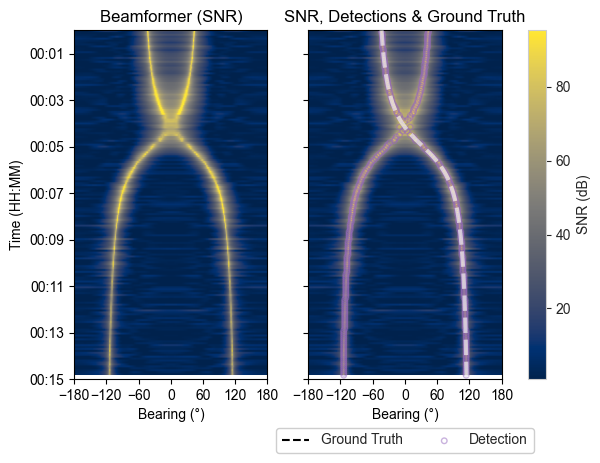

In [5]:
# ============================================================================
# VISUALIZATION
# ============================================================================

import matplotlib.pyplot as plt

timesteps = [
    SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    for i in range(SIM_PARAMS["num_steps"])
]

detections_for_plotter = [detection_set for _, detection_set in all_detections]

# Plot 1: Beamformer output with detections
fig1, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

style_guide = {
    "figure": {
        "figsize": (4, 4),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

# Left: Raw SNR (exclude last timestep)
plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=[],
    truths=[],
    ax=axs[0],
    add_colorbar=False
)
axs[0].set_title("Beamformer (SNR)")

# Right: SNR with detections and truth (exclude last timestep)
_, im = plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=detections_for_plotter[:-1],
    truths=relative_bearing_ground_truths,
    ax=axs[1],
    add_colorbar=False
)
axs[1].set_ylabel("")
axs[1].set_title(f"SNR, Detections & Ground Truth")

# Add shared colorbar
fig1.colorbar(im, ax=axs.tolist(), label='SNR (dB)')

# plt.suptitle(
#     f"Random Scenario: {NUM_TARGETS} Targets, {ARRAY_PARAMS['num_sensors']} Sensors",
#     fontsize=14,
#     fontweight="bold",
#     y=1.02
# )

plt.savefig("figs/single_target_beamform.png", dpi=300)



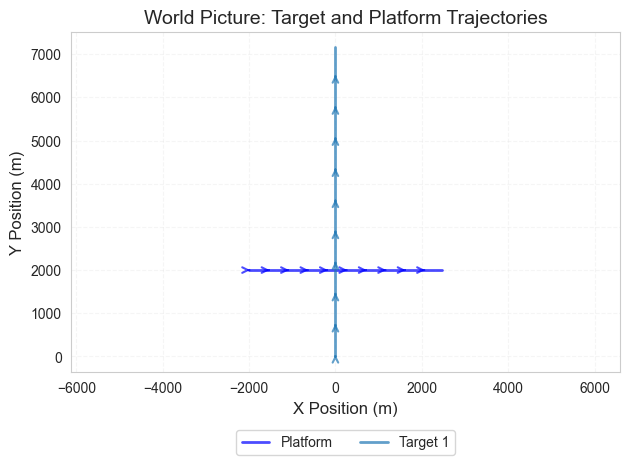

In [6]:
# Plot 2: Trajectories in Cartesian space
fig2, ax_path = plt.subplots()

# Extract platform positions
platform_x = []
platform_y = []
array_x = []
array_y = []

for timestamp in timesteps:
    platform_state = platform.get_platform_state_at(timestamp)
    platform_x.append(platform_state.host.state.state_vector[0])
    platform_y.append(platform_state.host.state.state_vector[2])
    
    array_center = np.mean(platform_state.array.state_vector, axis=1)
    array_x.append(array_center[0])
    array_y.append(array_center[1])

# Plot platform trajectory with direction arrows
ax_path.plot(platform_x, platform_y, 'b-', label='Platform', linewidth=2, alpha=0.7)
# ax_path.plot(array_x, array_y, 'g--', label='Array Center', linewidth=1.5, alpha=0.6)

# Add direction arrows for platform (every 10th point to avoid clutter)
arrow_interval = max(1, len(platform_x) // 10)
for i in range(0, len(platform_x) - 1, arrow_interval):
    dx = platform_x[i + 1] - platform_x[i]
    dy = platform_y[i + 1] - platform_y[i]
    ax_path.annotate('', xy=(platform_x[i + 1], platform_y[i + 1]), 
                    xytext=(platform_x[i], platform_y[i]),
                    arrowprops=dict(arrowstyle='->', color='blue', lw=1.5, alpha=0.7))

# Plot target trajectories with different colors
colors = plt.cm.tab10(np.linspace(0, 1, NUM_TARGETS))

for target_idx, target_ground_truth in enumerate(target_ground_truths):
    target_x = [state.state_vector[0] for state in target_ground_truth]
    target_y = [state.state_vector[2] for state in target_ground_truth]
    
    color = colors[target_idx]
    ax_path.plot(target_x, target_y, '-', color=color, 
                label=f'Target {target_idx + 1}', linewidth=2, alpha=0.7)
    
    # Add direction arrows for each target (every 10th point)
    for i in range(0, len(target_x) - 1, arrow_interval):
        dx = target_x[i + 1] - target_x[i]
        dy = target_y[i + 1] - target_y[i]
        ax_path.annotate('', xy=(target_x[i + 1], target_y[i + 1]), 
                        xytext=(target_x[i], target_y[i]),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.7))

ax_path.set_xlabel('X Position (m)', fontsize=12)
ax_path.set_ylabel('Y Position (m)', fontsize=12)
ax_path.set_title(f'World Picture: Target and Platform Trajectories', fontsize=14)
ax_path.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=10, ncol=4)
ax_path.grid(True, alpha=0.3)
ax_path.axis('equal')
plt.tight_layout()

plt.savefig("figs/single_target_world_picture.png", dpi=300)



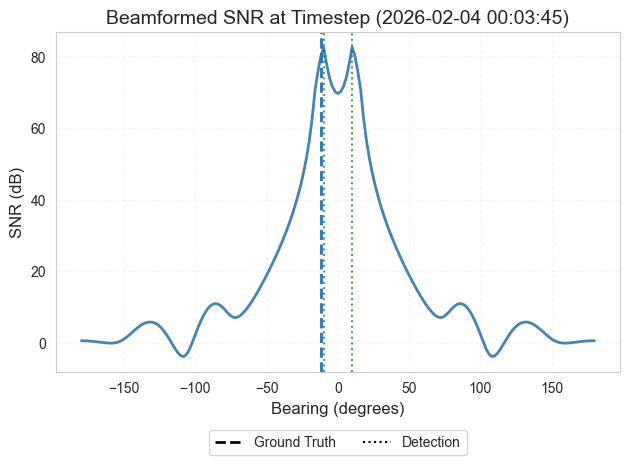

In [7]:
# Plot 3: Beamformed SNR at middle timestep
fig3, ax_middle = plt.subplots()

middle_timestep_idx = SIM_PARAMS["num_steps"] // 4
middle_snr = snr_map[middle_timestep_idx, :]
middle_time = timesteps[middle_timestep_idx]

steering_azimuths_deg = np.rad2deg(BF_PARAMS["steering_azimuths_rad"])
ax_middle.plot(steering_azimuths_deg, middle_snr, linewidth=2, color='steelblue')
ax_middle.set_xlabel('Bearing (degrees)', fontsize=12)
ax_middle.set_ylabel('SNR (dB)', fontsize=12)
ax_middle.set_title(f'Beamformed SNR at Timestep ({middle_time})', fontsize=14)
ax_middle.grid(True, alpha=0.3)

# Mark ground truth bearings for all targets
for target_idx, gt_relative_bearings in enumerate([
    [state.state_vector[0] for state in gt_path.states] 
    for gt_path in relative_bearing_ground_truths
]):
    gt_bearing_deg = np.rad2deg(gt_relative_bearings[middle_timestep_idx])
    color = colors[target_idx]
    ax_middle.axvline(gt_bearing_deg, color=color, linestyle='--', linewidth=2, 
                     label=f'Target {target_idx + 1} GT ({gt_bearing_deg:.1f}°)')

# Mark detections at this timestep if any
if len(detections_for_plotter[middle_timestep_idx]) > 0:
    for det_idx, det in enumerate(detections_for_plotter[middle_timestep_idx]):
        det_bearing_deg = np.rad2deg(det.state_vector[0])
        label = 'Detections' if det_idx == 0 else None
        ax_middle.axvline(det_bearing_deg, color='green', linestyle=':', linewidth=1.5, 
                        label=label, alpha=0.7)

# Create custom legend handles
from matplotlib.lines import Line2D
custom_handles = [
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Ground Truth'),
    Line2D([0], [0], color='black', linestyle=':', linewidth=1.5, label='Detection')
]
ax_middle.legend(handles=custom_handles, loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=10, ncol=2)
plt.tight_layout()




# TARGET TRACKING

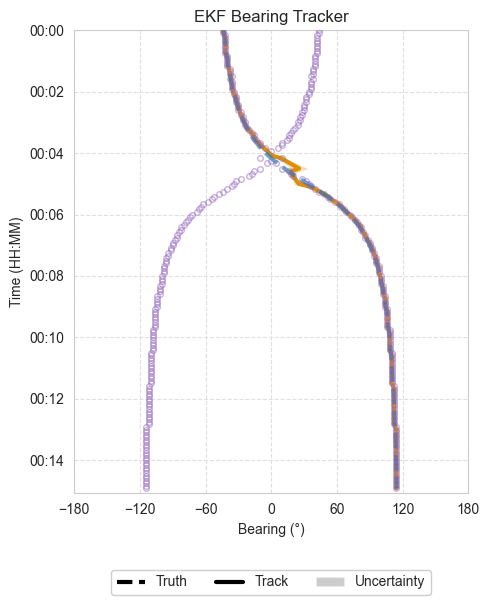

In [8]:
# ============================================================================
# TARGET TRACKING
# ============================================================================

from stonesoup.dataassociator.probability import PDA
from stonesoup.functions import (
    gm_reduce_single,  # For merging states to get posterior estimate
)
from stonesoup.hypothesiser.probability import PDAHypothesiser
from stonesoup.models.measurement.linear import LinearGaussian
from stonesoup.models.transition.linear import ConstantVelocity
from stonesoup.predictor.kalman import KalmanPredictor
from stonesoup.types.array import StateVectors
from stonesoup.types.state import GaussianState
from stonesoup.types.track import Track
from stonesoup.types.update import GaussianStateUpdate  # To store posterior estimate
from stonesoup.updater.kalman import ExtendedKalmanUpdater

# 1. Transition Model and Predictor
transition_model = ConstantVelocity(0.000001)
predictor = KalmanPredictor(transition_model)

# 2. Measurement Model and Updater
measurement_model = LinearGaussian(
    ndim_state=2,
    mapping=[0],
    noise_covar=np.array([[np.deg2rad(1)**2]])
)
updater = ExtendedKalmanUpdater(measurement_model=measurement_model)

# 3. Hypothesiser and Data Associator
hypothesiser = PDAHypothesiser(
    predictor=predictor,
    updater=updater,
    clutter_spatial_density=5/np.pi,
    prob_detect=0.95
)
data_associator = PDA(hypothesiser=hypothesiser)

# 5. Manually Create Initial Track
# Get the initial ground truth bearing and add some noise
initial_bearing = relative_bearing_ground_truth[0].state_vector[0] + \
    np.random.normal(0, np.deg2rad(2))
initial_state_vector = np.array([initial_bearing, 0]) # Assume initial bearing rate is 0

# Define initial state with uncertainty
prior_state = GaussianState(
    initial_state_vector,
    np.diag([np.deg2rad(5)**2, np.deg2rad(0.5)**2]),
    timestamp=SIM_PARAMS["start_time"]
)

# Create a track object
track = Track([prior_state])

# 7. Run Tracker
for timestamp, detections in all_detections:
    hypotheses = data_associator.associate(
        {track},
        detections,
        timestamp
    )

    hypotheses = hypotheses[track]

    posterior_states = []
    posterior_state_weights = []
    for hypothesis in hypotheses:
        if not hypothesis:
            posterior_states.append(hypothesis.prediction)
        else:
            posterior_state = updater.update(hypothesis)
            posterior_states.append(posterior_state)
        posterior_state_weights.append(hypothesis.probability)

    means = StateVectors([state.state_vector for state in posterior_states])
    covars = np.stack([state.covar for state in posterior_states], axis=2)
    weights = np.asarray(posterior_state_weights)

    # Reduce mixture of states to one posterior Gaussian estimate
    post_mean, post_covar = gm_reduce_single(means, covars, weights)

    # Add a Gaussian state approximation to the track
    track.append(
        GaussianStateUpdate(
            post_mean, post_covar,
            hypotheses,
            hypotheses[0].measurement.timestamp
        )
    )

style_guide = {
    "figure": {
        "figsize": (5, 6),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

plotter.plot(
    truths=[relative_bearing_ground_truth],
    tracks=[track],
    all_detections=detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    plot_uncertainty=True
)
plt.title("EKF Bearing Tracker")

plt.savefig("figs/single_target_bearing_tracker.png", dpi=300)

/home/fin/Documents/python/nereus/nereus/plotter.py:238: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.tight_layout()


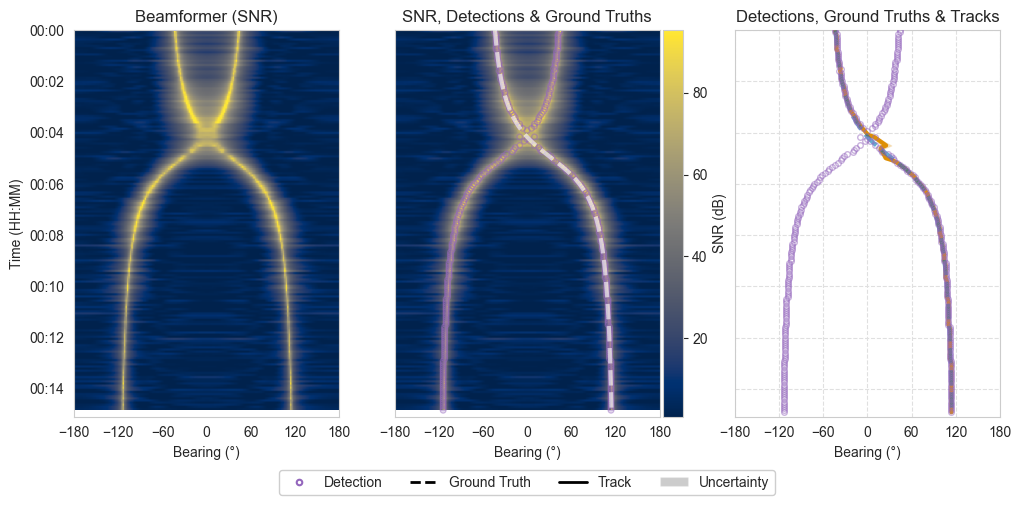

In [9]:
# Beamformer output with detections and tracks
fig1, axs = plt.subplots(1, 3, figsize=(10, 4.8), sharey=True, tight_layout=True)

style_guide = {
    "figure": {
        "figsize": (3, 4),
        "font_size": 10
    },
    "legend": {
        "display": False,  # Disable legend on RHS plot
    },
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

# Left: Raw SNR (exclude last timestep)
plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=[],
    truths=[],
    ax=axs[0],
    add_colorbar=False,
    add_legend=False
)
axs[0].set_title("Beamformer (SNR)")

# Middle: SNR with detections and truth (exclude last timestep)
_, im = plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=detections_for_plotter[:-1],
    truths=relative_bearing_ground_truths,
    ax=axs[1],
    add_colorbar=False,
    add_legend=False
)
axs[1].set_ylabel("")
axs[1].set_title(f"SNR, Detections & Ground Truths")

# Add shared colorbar
fig1.colorbar(im, ax=axs.tolist(), label='SNR (dB)', anchor=(-1.5, 0.5))

# Right: Detections, Ground Truths & Tracks (no legend)
plotter.plot(
    truths=relative_bearing_ground_truths,
    tracks=[track],
    all_detections=detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    ax=axs[2],
    plot_uncertainty=True
)
axs[2].set_ylabel("")
axs[2].set_title(f"Detections, Ground Truths & Tracks")
pos = axs[2].get_position()
axs[2].set_position([pos.x0 + 0.02, pos.y0, pos.width, pos.height])

# Create unified legend under middle plot
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
           markeredgecolor="#9467bd", markersize=4, markeredgewidth=1.5, 
           label='Detection', linestyle='None'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, 
           label='Ground Truth'),
    Line2D([0], [0], color='black', linestyle='-', linewidth=2, 
           label='Track'),
    Patch(facecolor='black', alpha=0.2, label='Uncertainty'),
]

axs[1].legend(handles=legend_elements, loc='upper center', 
              bbox_to_anchor=(0.5, -0.12), ncol=4, 
              fancybox=True, shadow=False, frameon=True, framealpha=0.95)

plt.savefig("figs/single_target_beamformer_tracker.png", dpi=300, bbox_inches='tight')

# STONE SOUP DECTIONS

Using clutter spatial density: 0.1592 per radian
Using clutter spatial density: 0.0028 per degree


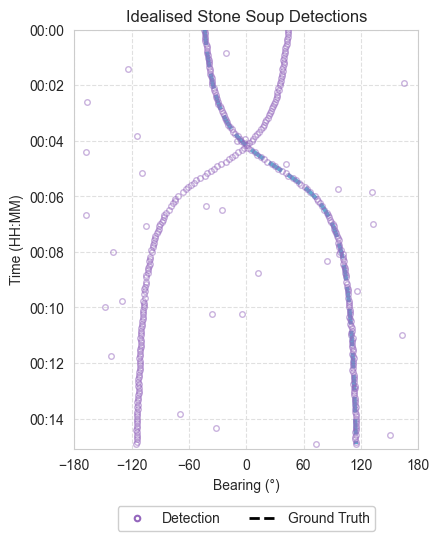

In [10]:
# ============================================================================
# STONE SOUP DECTIONS
# ============================================================================

from stonesoup.types.detection import Detection
from scipy.stats import uniform

from stonesoup.functions import mod_bearing

# Measurement model for detection generation (1D state -> 1D measurement)
deg_std = 0.5
detection_measurement_model = LinearGaussian(
    ndim_state=1,
    mapping=[0],
    noise_covar=np.array([[np.deg2rad(deg_std)**2]])
)

# Measurement model for tracking (2D state -> 1D measurement)
ss_measurement_model = LinearGaussian(
    ndim_state=2,
    mapping=[0],
    noise_covar=np.array([[np.deg2rad(deg_std)**2]])
)

# Detection parameters
FOV_RAD = np.deg2rad(360)
expected_false_alarms_per_scan = 1
clutter_spatial_density = expected_false_alarms_per_scan / FOV_RAD
print(f"Using clutter spatial density: {clutter_spatial_density:.4f} per radian")
print(f"Using clutter spatial density: {expected_false_alarms_per_scan/360:.4f} per degree")
prob_detection = 0.95

# Generate detections from ground truth
stone_soup_detections = []

for i, timestamp in enumerate(timesteps):
    detections_at_time = []
    
    # Generate true detections from each target
    for gt_bearing_path in relative_bearing_ground_truths:
        if np.random.rand() < prob_detection:
            # Use measurement model to generate noisy measurement
            measurement = detection_measurement_model.function(gt_bearing_path[i], noise=True)
            
            detection = Detection(
                state_vector=measurement,
                timestamp=timestamp,
                measurement_model=ss_measurement_model
            )
            detections_at_time.append(detection)
            detection_mirrored = Detection(
                state_vector=-measurement,
                timestamp=timestamp,
                measurement_model=ss_measurement_model
            )
            detections_at_time.append(detection_mirrored)
    
    # Add clutter/false alarms
    num_clutter = np.random.poisson(clutter_spatial_density)
    for _ in range(num_clutter):
        clutter_bearing = uniform.rvs(loc=-np.pi, scale=2*np.pi)
        clutter_detection = Detection(
            state_vector=np.array([[clutter_bearing]]),
            timestamp=timestamp,
            measurement_model=ss_measurement_model
        )
        detections_at_time.append(clutter_detection)
    
    stone_soup_detections.append((timestamp, detections_at_time))

# Convert to format compatible with plotter
ss_detections_for_plotter = [detection_set for _, detection_set in stone_soup_detections]

style_guide = {
    "figure": {
        "figsize": (4.5, 5.5),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

plotter.plot(
    truths=relative_bearing_ground_truths,
    tracks=[],
    all_detections=ss_detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    plot_uncertainty=True
)

plt.title("Idealised Stone Soup Detections")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
           markeredgecolor='#9467bd', markersize=4, markeredgewidth=1.5, 
           label='Detection', linestyle='None'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, 
           label='Ground Truth'),
]

plt.legend(handles=legend_elements, loc='upper center', 
              bbox_to_anchor=(0.5, -0.12), ncol=4, 
              fancybox=True, shadow=False, frameon=True, framealpha=0.95)

plt.savefig("figs/single_target_ideal_ss_det.png", dpi=300)

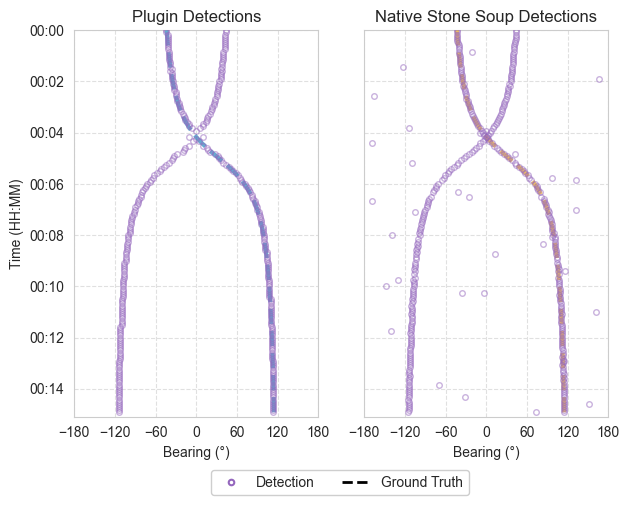

In [11]:
# plot nereus detections and ss detections side by side


fig1, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

style_guide = {
    "figure": {
        "figsize": (4, 4),
        "font_size": 10
    },
    "legend": {
        "display": False,  # Disable legend on RHS plot
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

plotter.plot(
    truths=relative_bearing_ground_truths,
    tracks=[],
    all_detections=detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    plot_uncertainty=True,
    ax=axs[0],
)
axs[0].set_title("Plugin Detections")

plotter.plot(
    truths=relative_bearing_ground_truths,
    tracks=[],
    all_detections=ss_detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    plot_uncertainty=True,
    ax=axs[1],
)
axs[1].set_ylabel("")
axs[1].set_title(f"Native Stone Soup Detections")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
           markeredgecolor='#9467bd', markersize=4, markeredgewidth=1.5, 
           label='Detection', linestyle='None'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, 
           label='Ground Truth'),
]

plt.legend(handles=legend_elements, loc='upper center', 
              bbox_to_anchor=(-0.1, -0.12), ncol=4, 
              fancybox=True, shadow=False, frameon=True, framealpha=0.95)


plt.savefig("figs/single_target_plugin_vs_ss_det.png", dpi=300, bbox_inches='tight')

# CYLINDRICAL TL

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


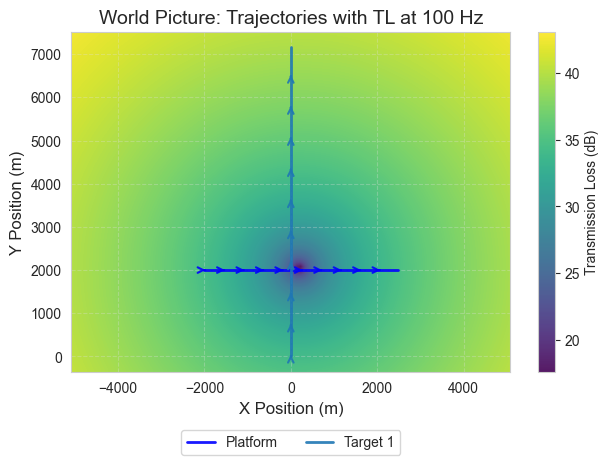

In [56]:
# ============================================================================
# CYLINDRICAL TL
# ============================================================================

# Plot 2: Trajectories in Cartesian space with TL background
fig2, ax_path = plt.subplots()

# Extract platform positions
platform_x = []
platform_y = []
array_x = []
array_y = []

for timestamp in timesteps:
    platform_state = platform.get_platform_state_at(timestamp)
    platform_x.append(platform_state.host.state.state_vector[0])
    platform_y.append(platform_state.host.state.state_vector[2])
    
    array_center = np.mean(platform_state.array.state_vector, axis=1)
    array_x.append(array_center[0])
    array_y.append(array_center[1])

# Select timestep for TL computation (change index as needed)
tl_timestep_idx = 0  # 0 = first, len(timesteps)//2 = middle, -1 = last
tl_timestep_idx = len(timesteps)//2
tl_timestep = timesteps[tl_timestep_idx]

# Get array position at selected timestep
selected_platform_state = platform.get_platform_state_at(tl_timestep)
array_ref_pos = selected_platform_state.array.ref_state_vector

# Get array position at first timestep
first_platform_state = platform.get_platform_state_at(timesteps[0])
array_ref_pos = first_platform_state.array.ref_state_vector

# Create spatial grid with extended range to cover entire background
all_x = platform_x + [state.state_vector[0] for gt in target_ground_truths for state in gt]
all_y = platform_y + [state.state_vector[2] for gt in target_ground_truths for state in gt]

# Determine the data range
data_x_range = (min(all_x), max(all_x))
data_y_range = (min(all_y), max(all_y))
data_x_span = data_x_range[1] - data_x_range[0]
data_y_span = data_y_range[1] - data_y_range[0]
x_center = (data_x_range[0] + data_x_range[1]) / 2
y_center = (data_y_range[0] + data_y_range[1]) / 2

# Add padding to y range
padding_factor = 1.1
y_range = (y_center - data_y_span / 2 * padding_factor, y_center + data_y_span / 2 * padding_factor)
y_span_total = y_range[1] - y_range[0]

# Set x range to match y range span (for square grid with equal aspect)
x_range = (x_center - y_span_total / 2 - 2000, x_center + y_span_total / 2 + 2000)

grid_resolution = 100  # meters
x_grid = np.arange(x_range[0], x_range[1], grid_resolution)
y_grid = np.arange(y_range[0], y_range[1], grid_resolution)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

# Compute TL for each grid point
TL_grid = np.zeros_like(X_grid)
# source_is_grid = False
source_x, source_y, source_z = 0.0, 0.0, -50.0  # Fixed source position
# receiver_is_grid = True

# TL Configuration: Choose ONE option by commenting/uncommenting
# ===============================================================
rcvr_as_source = True
target_as_source = False
custom_source = False

if rcvr_as_source:
    # OPTION 1: Grid points as sources → array as receiver (DEFAULT)
    for i in range(X_grid.shape[0]):
        for j in range(X_grid.shape[1]):
            grid_pos = np.array([[X_grid[i, j]], [0.0], [Y_grid[i, j]], [0.0], [array_ref_pos[2]], [0.0]])
            mock_source = GroundTruthState(grid_pos, timestamp=tl_timestep)
            mock_source.metadata = {
                'position_mapping': [0, 2, 4],
                'frequencies_hz': [100.0],
                'amplitudes_upa': [1.0]
            }
            tloss, _ = prop_model.propagate(selected_platform_state, mock_source)
            TL_grid[i, j] = tloss

if custom_source:
    # OPTION 2: Fixed source → grid points as receivers (UNCOMMENT TO USE)
    source_x, source_y, source_z = 0.0, 0.0, -50.0  # Set source position here
    source_pos = np.array([[source_x], [0.0], [source_y], [0.0], [source_z], [0.0]])
    fixed_source = GroundTruthState(source_pos, timestamp=tl_timestep)
    fixed_source.metadata = {
        'position_mapping': [0, 2, 4],
        'frequencies_hz': [100.0],
        'amplitudes_upa': [1.0]
    }
    for i in range(X_grid.shape[0]):
        for j in range(X_grid.shape[1]):
            grid_state = GroundTruthState(
                np.array([[X_grid[i, j]], [0.0], [Y_grid[i, j]], [0.0], [array_ref_pos[2]], [0.0]]),
                timestamp=tl_timestep
            )
            mock_platform = TowedArrayPlatform(
                states=[grid_state],
                position_mapping=[0, 2, 4],
                velocity_mapping=[1, 3, 5],
                transition_model=SHIP_PARAMS["transition_model"],
                num_sensors=1,
                cable_length_m=0.0,
                sensor_spacing_m=0.5,
                array_depth_m=array_ref_pos[2],
            )
            tloss, _ = prop_model.propagate(mock_platform.get_platform_state_at(tl_timestep), fixed_source)
            TL_grid[i, j] = tloss

if target_as_source:
    # OPTION 3: Target as source → grid points as receivers (UNCOMMENT TO USE)
    target_state = target_ground_truths[0][tl_timestep_idx]  # First target at selected timestep
    target_pos = target_state.state_vector[target_state.metadata['position_mapping']]
    source_pos = np.array([[target_pos[0]], [0.0], [target_pos[1]], [0.0], [target_pos[2]], [0.0]])
    target_source = GroundTruthState(source_pos, timestamp=tl_timestep)
    target_source.metadata = {
        'position_mapping': [0, 2, 4],
        'frequencies_hz': [100.0],
        'amplitudes_upa': [1.0]
    }
    for i in range(X_grid.shape[0]):
        for j in range(X_grid.shape[1]):
            grid_state = GroundTruthState(
                np.array([[X_grid[i, j]], [0.0], [Y_grid[i, j]], [0.0], [array_ref_pos[2]], [0.0]]),
                timestamp=tl_timestep
            )
            mock_platform = TowedArrayPlatform(
                states=[grid_state],
                position_mapping=[0, 2, 4],
                velocity_mapping=[1, 3, 5],
                transition_model=SHIP_PARAMS["transition_model"],
                num_sensors=1,
                cable_length_m=0.0,
                sensor_spacing_m=0.5,
                array_depth_m=array_ref_pos[2],
            )
            tloss, _ = prop_model.propagate(mock_platform.get_platform_state_at(tl_timestep), target_source)
            TL_grid[i, j] = tloss


# Plot TL as background using imshow
extent = [x_range[0], x_range[1], y_range[0], y_range[1]]
im = ax_path.imshow(TL_grid, extent=extent, origin='lower', cmap='viridis', alpha=0.9, aspect='equal', interpolation='bilinear')
cbar = plt.colorbar(im, ax=ax_path, label='Transmission Loss (dB)')


# Plot platform trajectory with direction arrows
ax_path.plot(platform_x, platform_y, 'b-', label='Platform', linewidth=2, alpha=0.9)

# Add direction arrows for platform (every 10th point to avoid clutter)
arrow_interval = max(1, len(platform_x) // 10)
for i in range(0, len(platform_x) - 1, arrow_interval):
    dx = platform_x[i + 1] - platform_x[i]
    dy = platform_y[i + 1] - platform_y[i]
    ax_path.annotate('', xy=(platform_x[i + 1], platform_y[i + 1]), 
                    xytext=(platform_x[i], platform_y[i]),
                    arrowprops=dict(arrowstyle='->', color='blue', lw=1.5, alpha=0.9))

# Plot target trajectories with different colors
colors = plt.cm.tab10(np.linspace(0, 1, NUM_TARGETS))

for target_idx, target_ground_truth in enumerate(target_ground_truths):
    target_x = [state.state_vector[0] for state in target_ground_truth]
    target_y = [state.state_vector[2] for state in target_ground_truth]
    
    color = colors[target_idx]
    ax_path.plot(target_x, target_y, '-', color=color, 
                label=f'Target {target_idx + 1}', linewidth=2, alpha=0.9)
    
    # Add direction arrows for each target (every 10th point)
    for i in range(0, len(target_x) - 1, arrow_interval):
        dx = target_x[i + 1] - target_x[i]
        dy = target_y[i + 1] - target_y[i]
        ax_path.annotate('', xy=(target_x[i + 1], target_y[i + 1]), 
                        xytext=(target_x[i], target_y[i]),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.9))

ax_path.set_xlabel('X Position (m)', fontsize=12)
ax_path.set_ylabel('Y Position (m)', fontsize=12)
ax_path.set_title(f'World Picture: Trajectories with TL at 100 Hz', fontsize=14)
ax_path.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=10, ncol=4)
ax_path.grid(True, alpha=0.3)
ax_path.axis('equal')
ax_path.set_xlim(-2500, 2500)
# ax_path.set_ylim(-500, 7500)
plt.tight_layout()

# plt.savefig("figs/single_target_world_picture_TL_background.png", dpi=300)


In [57]:
# ============================================================================
# PRINT SUMMARY
# ============================================================================

print()
print("=" * 80)
print("Random Scenario Summary:")
print("=" * 80)
print(f"  Seed: {seed}")
print(f"  Number of Targets: {NUM_TARGETS}")
print(f"  Simulation Duration: {total_duration_s} s across {SIM_PARAMS['num_steps']} timesteps")
print(f"  Timestep Interval: {SIM_PARAMS['time_interval'].total_seconds()} s")
print(f"  Array: {ARRAY_PARAMS['num_sensors']} sensors, {ARRAY_PARAMS['sensor_spacing']} m spacing")
print(f"  Signal Sampling Rate: {SIGNAL_PARAMS['sampling_rate_hz']} Hz")
print(f"  Ambient Noise Level: {20 * np.log10(AMBIENT_NOISE_PARAMS['amplitude_upa']):.1f} dB re 1 µPa")
print(f"  Steering Directions: {len(BF_PARAMS['steering_azimuths_rad'])}")
print(f"  Num sensors: {ARRAY_PARAMS['num_sensors']}")
print(f"  Sensor Spacing: {ARRAY_PARAMS['sensor_spacing']} m")
print(f"  Array length: {ARRAY_PARAMS['num_sensors']*ARRAY_PARAMS['sensor_spacing']} m")
print()
print("  Platform Initial State:")
print(f"    Position: ({SHIP_PARAMS['start_vector'][0]:.0f}, {SHIP_PARAMS['start_vector'][2]:.0f}) m")
print(f"    Velocity: ({SHIP_PARAMS['start_vector'][1]:.1f}, {SHIP_PARAMS['start_vector'][3]:.1f}) m/s")
print()
for target_idx, TARGET_PARAMS in enumerate(TARGETS):
    print(f"  Target {target_idx + 1}:")
    print(f"    Frequencies: {TARGET_PARAMS['frequencies_hz']} Hz")
    print(f"    Amplitudes: {20 * np.log10(TARGET_PARAMS['amplitudes_upa'])} dB re 1 µPa")
    print(f"    Start Position: ({TARGET_PARAMS['start_vector'][0]:.0f}, {TARGET_PARAMS['start_vector'][2]:.0f}) m")
    print(f"    Velocity: ({TARGET_PARAMS['start_vector'][1]:.1f}, {TARGET_PARAMS['start_vector'][3]:.1f}) m/s")
    print(f"    Tonal Bandwidth: {TARGET_PARAMS['tonal_bandwidth_hz']:.2f} Hz")
    print(f"    Noise Level: {20 * np.log10(TARGET_PARAMS['noise_amplitude_upa']):.1f} dB re 1 µPa")

plt.show()



Random Scenario Summary:
  Seed: 2000
  Number of Targets: 1
  Simulation Duration: 900.0 s across 180 timesteps
  Timestep Interval: 5.0 s
  Array: 50 sensors, 0.5 m spacing
  Signal Sampling Rate: 500.0 Hz
  Ambient Noise Level: 48.6 dB re 1 µPa
  Steering Directions: 181
  Num sensors: 50
  Sensor Spacing: 0.5 m
  Array length: 25.0 m

  Platform Initial State:
    Position: (-2000, 2000) m
    Velocity: (5.0, 0.0) m/s

  Target 1:
    Frequencies: [ 90.77693112 118.10627705  36.91860048 127.29258553] Hz
    Amplitudes: [95.55775928 95.46793133 94.32662749 92.0471663 ] dB re 1 µPa
    Start Position: (0, 0) m
    Velocity: (0.0, 8.0) m/s
    Tonal Bandwidth: 0.99 Hz
    Noise Level: 78.9 dB re 1 µPa
